In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('IPLPlayerStat.csv')
df.head()

,Unnamed: 0,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
0,0,A Ashish Reddy,280,31,196,18.0,270.0,400.0,28,10.00,142.86,15.82,8.89,22.22,15.00,8.0,0.0
1,1,A Badoni,161,18,139,2.0,12.0,12.0,11,14.64,115.83,12.95,6.00,6.00,6.00,8.0,0.0
2,2,A Chandila,4,0,7,11.0,234.0,245.0,12,0.33,57.14,0.00,6.28,22.27,21.27,2.0,0.0
3,3,A Chopra,53,7,75,0.0,0.0,0.0,6,8.83,70.67,9.33,0.00,0.00,0.00,2.0,0.0
4,4,A Choudhary,25,2,20,5.0,108.0,144.0,5,5.00,125.00,10.00,8.00,28.80,21.60,0.0,0.0


In [3]:
df[['batting_strike_rate']].head()

,batting_strike_rate
0,142.86
1,115.83
2,57.14
3,70.67
4,125.00


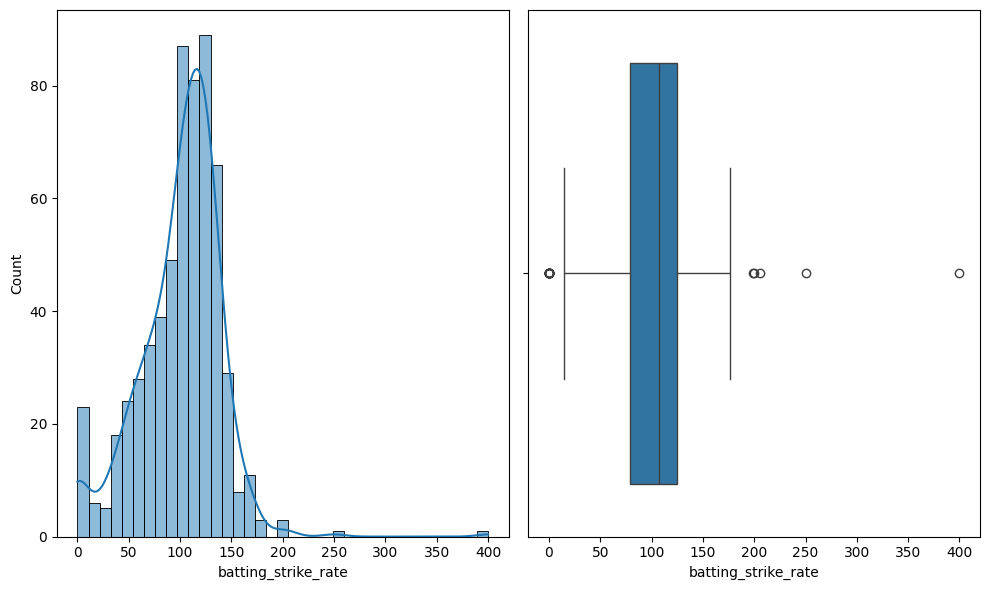

In [8]:
plt.figure(figsize=(10,6))

plt.subplot(1,2,1)
sns.histplot(df['batting_strike_rate'], kde = True)

plt.subplot(1,2,2)
sns.boxplot(x=df['batting_strike_rate'])

plt.tight_layout()

plt.show()

In [10]:
Q1 = df['batting_strike_rate'].quantile(0.25)
Q3 = df['batting_strike_rate'].quantile(0.75)

median = df['batting_strike_rate'].quantile(0.5)

IQR = Q3- Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

print("Q1 : ", Q1)
print("Q3 : ", Q3)
print("Median : ", median)
print("IQR : ", IQR)
print("Lower : ", lower)
print("Upper : ", upper)

Q1 :  78.75
Q3 :  125.0
Median :  107.27
IQR :  46.25
Lower :  9.375
Upper :  194.375


In [15]:
outliers = df[(df['batting_strike_rate']<lower) | (df['batting_strike_rate']>upper)]
print("Number of Outliers is : ", len(outliers))
outliers.head()

Number of Outliers is :  28


,Unnamed: 0,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
57,57,AS Roy,0,0,2,2.0,57.0,66.0,3,0.00,0.0,0.0,6.95,33.00,28.50,5.0,0.0
63,63,Abdur Razzak,0,0,2,0.0,14.0,29.0,1,0.00,0.0,0.0,12.43,290000.00,140000.00,0.0,0.0
65,65,Akash Deep,0,0,2,5.0,119.0,206.0,5,0.00,0.0,0.0,10.39,41.20,23.80,1.0,0.0
83,83,B Stanlake,5,1,2,7.0,150.0,200.0,6,0.83,250.0,50.0,8.00,28.57,21.43,1.0,0.0
102,102,C Nanda,0,0,1,2.0,50.0,58.0,3,0.00,0.0,0.0,6.96,29.00,25.00,0.0,0.0


In [18]:
# Trimming Outliers

trim_df =  df[(df['batting_strike_rate']>=lower) & (df['batting_strike_rate']<=upper)]

print("Original Shape : ", df.shape)
print("After Trimmin : ", trim_df.shape)

Original Shape :  (605, 17)
After Trimmin :  (577, 17)


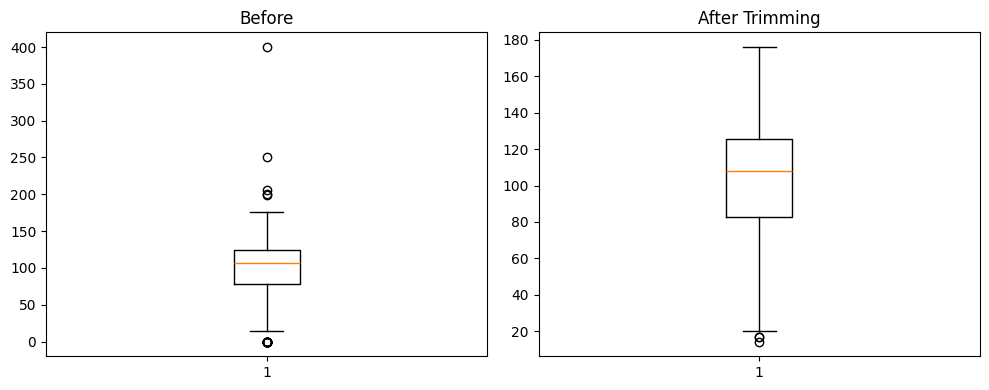

In [27]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.boxplot(x=df['batting_strike_rate'])
plt.title('Before')

plt.subplot(1,2,2)
plt.boxplot(x=trim_df['batting_strike_rate'])
plt.title('After Trimming')

plt.tight_layout()
plt.show()

In [31]:
# Capping (replace outlier with suitable value)
cap_df = df.copy()
cap_df['batting_strike_rate'] = cap_df['batting_strike_rate'].clip(lower, upper)

In [32]:
print("Original Shape : ", df.shape)
print("After Trimming : ",cap_df.shape)

Original Shape :  (605, 17)
After Trimming :  (605, 17)


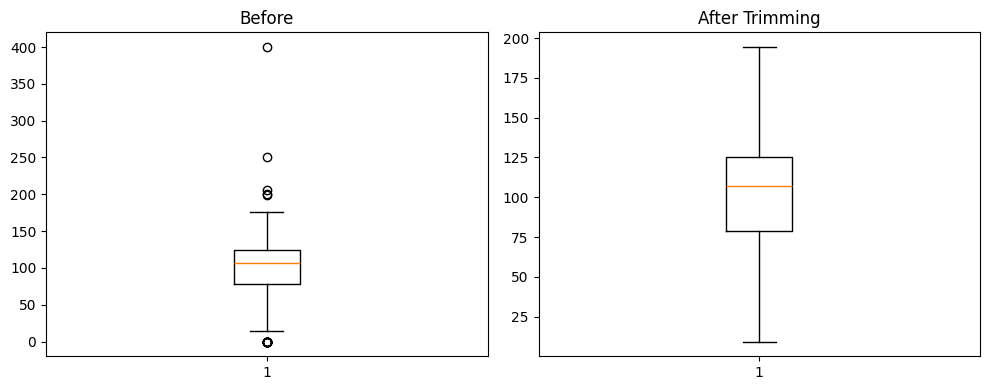

In [33]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.boxplot(x=df['batting_strike_rate'])
plt.title('Before')

plt.subplot(1,2,2)
plt.boxplot(x=cap_df['batting_strike_rate'])
plt.title('After Trimming')

plt.tight_layout()
plt.show()